## A Simple Kinetic Solver

This solver can solve the kinetics of condensation and evaporation in and out of an aerosol. Can be improved by extending to xyz systems.

In [1]:
# Installing Packages

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

from numpy import random


In [2]:
# Creating Inputs

# Initial random generator seed
seed = 42
rng = random.default_rng(seed)

# Update to realistic k values later...
kf = 0.01
kb = 0.01

# Calculation of equilibrium constant
K = kf/kb

time_step = 1 # second
total_time = 275 # seconds for total run
ntime = int(total_time / time_step) # total number of calculations

# Initial paramaters
mol_L = 990
mol_G = 10
time = 0

# Variables to be updated
L_remaining = mol_L
G_formed = mol_G

# Creating lists
L = []
G = []
times = []
sum_mol = []

In [3]:
# Loop over time

for t in range(ntime):

    time += time_step

    # Store current values
    L.append(L_remaining)
    G.append(G_formed)
    times.append(time)

    # First-order rates
    evaporation_rate = kf * L_remaining
    condensation_rate = kb * G_formed

    # Change in each species during this timestep
    dL = (-evaporation_rate + condensation_rate) * time_step
    dG = (evaporation_rate - condensation_rate) * time_step

    # Update populations
    L_remaining += dL
    G_formed += dG

    # Total molecules
    sum_mol.append(L_remaining + G_formed)

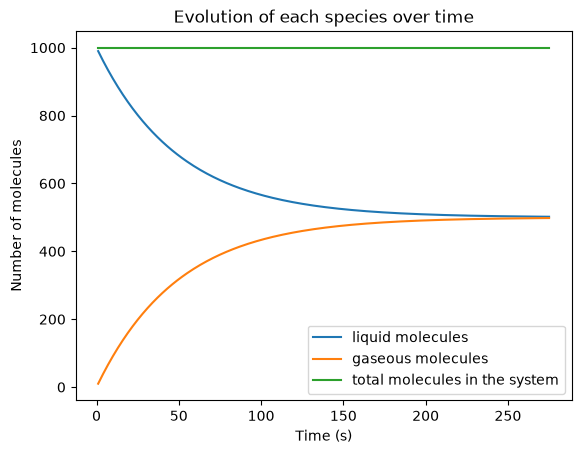

In [4]:
plt.plot(times, L, label="liquid molecules")
plt.plot(times, G, label="gaseous molecules")
plt.plot(times, sum_mol, label="total molecules in the system")

plt.title("Evolution of each species over time")
plt.xlabel("Time (s)")
plt.ylabel("Number of molecules")
plt.legend()
plt.show()